## Import Library

In [1]:
import numpy as np
import pandas as pd
import sympy 
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from sympy import init_printing
from sympy.utilities.lambdify import lambdify
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from matplotlib import cm  # colormap
init_printing(use_latex=True)

## Domain Discretization

Text(0, 0.5, '$y$')

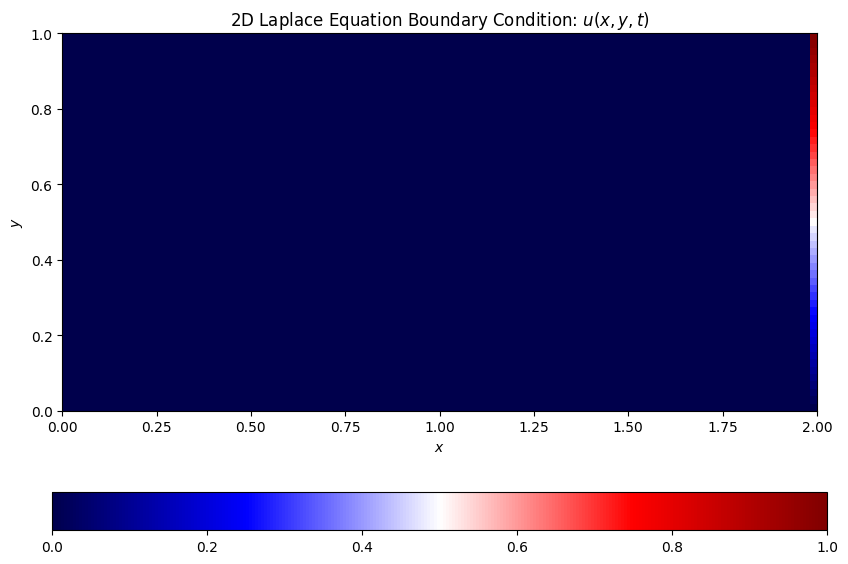

In [ ]:
#set several domain data discrete
element_num_x = 101 #we set 101
element_num_y = 51 #we set 51
a,b = 0,2 #set the x bound
c,d = 0,1 #set the y bound
dx = (b-a)/(element_num_x-1)  #set the dx length
dy = (d-c)/((element_num_y-1))  #set the dy length
convergence_res = 0.000001 #smaller means the source term diffuse better

#mesh to visualize and numerically matter
x_vals = np.linspace(a,b,element_num_x) #set the x axis
y_vals = np.linspace(c,d,element_num_y) #set the y axis
X, Y = np.meshgrid(x_vals, y_vals) #set for meshgrid

#set for boundary condition
p = np.zeros([element_num_y,element_num_x])
p[:,0] = 0      #set the x = 0 ,P = 0
p[:,100] = y_vals       #set the x = 2 ,P = y

fig, ax = plt.subplots(figsize=(10,7))  #initialize the figure by subplots
#solved up to two order fourrier series

# Inisialisasi heatmap awal
cax = ax.imshow(p, cmap='seismic', origin='lower', extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)], vmin=np.min(p), vmax=np.max(p)) #extent to visualize 
cbar = fig.colorbar(cax, ax=ax, orientation = 'horizontal')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.xaxis.tick_bottom()  # Put ticks on top
ax.set_title('2D Laplace Equation Boundary Condition: $u(x, y)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

## Laplace Equation Analytically

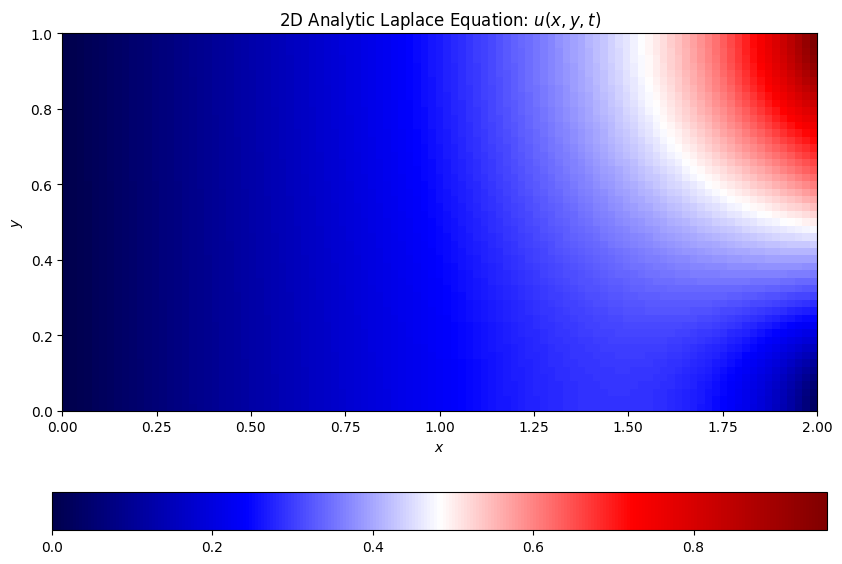

In [ ]:
def Laplace_Analytically(X,Y):

    fig, ax = plt.subplots(figsize=(10,7))  #initialize the figure by subplots

    #solved up to two order fourrier series
    P = X/4 - 4*(((np.sinh(np.pi*X)*np.cos(np.pi*Y))/((np.pi**2)*np.sinh(2*np.pi))) 
                 + ((np.sinh(3*np.pi*X)*np.cos(3*np.pi*Y))/(((3*np.pi)**2)*np.sinh(2*np.pi*3)))
                 + ((np.sinh(5*np.pi*X)*np.cos(5*np.pi*Y))/(((5*np.pi)**2)*np.sinh(2*np.pi*5))))

    # Inisialisasi heatmap awal
    cax = ax.imshow(P, cmap='seismic', origin='lower', extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)], vmin=np.min(P), vmax=np.max(P)) #extent to visualize 
    cbar = fig.colorbar(cax, ax=ax, orientation = 'horizontal')
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.xaxis.tick_bottom()  # Put ticks on top
    ax.set_title('2D Analytic Laplace Equation: $u(x, y)$')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

    return ax, P

res_1,res_2 = Laplace_Analytically(X,Y)

## Laplace Eqution Solved Numerically

In [ ]:
def Laplace_Numerically(y_vals,dx,dy,p,convergence_res):

    #set the similiar p for calculation framework
    l1norm = 1

    while l1norm > convergence_res:

        p_new = p.copy()
        #we calculate the horizontal first then vertically declined after the horizontal is done
        
        for i in range (1,len(p[:,0])-1): #define the y each iteration

            for j in range (1,len(p[0])-1): #define the x each iteration

                #numeric laplace procedure
                p_new[i,j] = (
                    ((p[i,j+1] + p[i,j-1]) * dy**2 +
                     (p[i+1,j] + p[i-1,j]) * dx**2)
                    / (2 * (dx**2 + dy**2))
                )
            
        p_new[:,0] = 0      #set the x = 0 ,P = 0 dirichlet
        p_new[:,-1] = y_vals       #set the x = 2 ,P = y dirichlet
        p_new[0,  :] = p_new[1, :]  #set the neumann boundary
        p_new[-1, :] = p_new[-2, :] #set the neumann boundary

        #calculate the error and pass to next calculation to reduce error
        l1norm = (np.sum(np.abs(p_new[:]) - np.abs(p[:]))/np.sum(np.abs(p[:])))
        print(f'convergence residual: {l1norm}')
        p = p_new

    return p_new

## Numeric Visualization

Text(0, 0.5, '$y$')

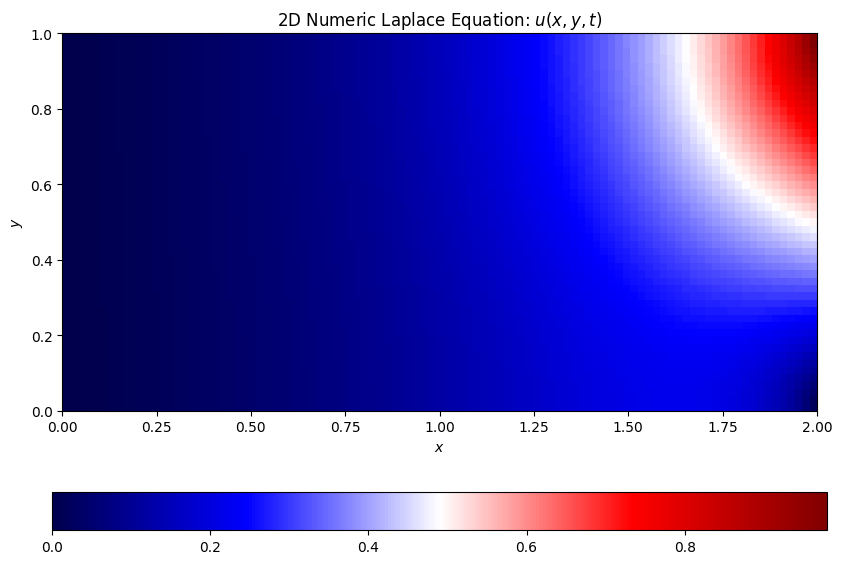

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))  #initialize the figure by subplots

P_numeric = Laplace_Numerically(y_vals,dx,dy,p, convergence_res)

# Inisialisasi heatmap awal
cax = ax.imshow(P_numeric, cmap='seismic', origin='lower', extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)], vmin=np.min(P_numeric), vmax=np.max(P_numeric)) #extent to visualize 
cbar = fig.colorbar(cax, ax=ax, orientation = 'horizontal')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.xaxis.tick_bottom()  # Put ticks on top
ax.set_title('2D Numeric Laplace Equation: $u(x, y)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

#res_1,res_2 = Laplace_Analytically(X,Y)

## L2 Error 

Text(0, 0.5, '$y$')

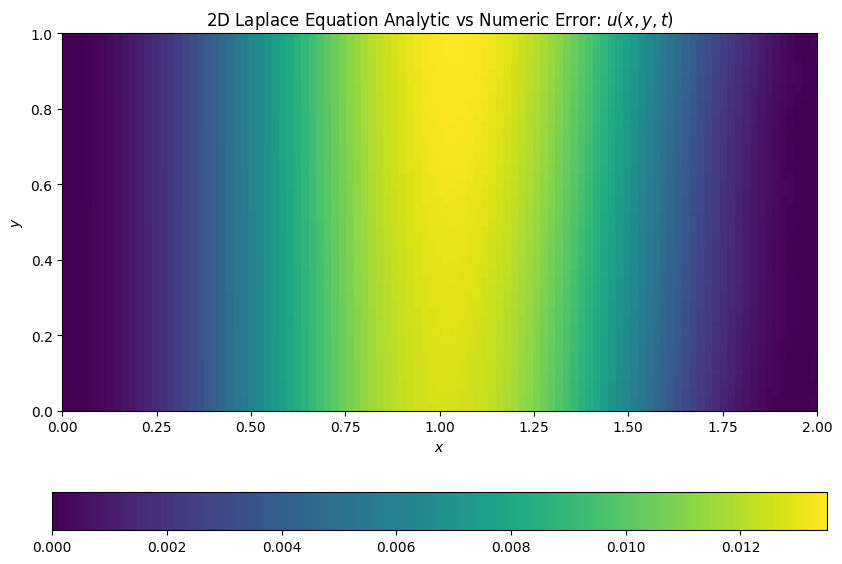

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))  #initialize the figure by subplots

error = np.square(P_numeric-res_2)

# Inisialisasi heatmap awal
cax = ax.imshow(error, origin='lower', extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)], vmin=np.min(error), vmax=np.max(error)) #extent to visualize 
cbar = fig.colorbar(cax, ax=ax, orientation = 'horizontal')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.xaxis.tick_bottom()  # Put ticks on top
ax.set_title('2D Laplace Equation Analytic vs Numeric Error: $u(x, y)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

#res_1,res_2 = Laplace_Analytically(X,Y)